# 处理AF3的预测结果并进行抽样，几何优化与训练；合并Rosetta的打分结果
## 统一数据集的格式

# 重新在AlphaFold3预测的结果中抽样，作为新的训练集掺入原始的Rosetta的数据集中进行训练

In [1]:
import pandas as pd
import numpy as np
import os

In [8]:
#读取/home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/bin2_groundtruth_common_parent_metrics.csv中的PDB名称
rosetta_df = pd.read_csv("./data/bin2_groundtruth_common_parent_metrics.csv")
pdbs = set([pdb.split("_")[0] for pdb in rosetta_df["PDB"].tolist()])
with open("./data/rosetta_pdbs.txt", "w") as f:
    for pdb in sorted(pdbs):
        f.write(pdb + "\n")


af_df = pd.read_csv("./data/af3_metrics_summary_with_labels.csv")
af_pdbs = set(af_df["target"].tolist())
with open("./data/af3_pdbs.txt", "w") as f:
    for pdb in sorted(af_pdbs):
        f.write(pdb + "\n")


diff = af_pdbs - pdbs
print("AF3独有的PDB数量：", len(diff))
print("AF3独有的PDB列表：", sorted(diff))
diff = pdbs - af_pdbs
print("Rosetta独有的PDB数量：", len(diff))
print("Rosetta独有的PDB列表：", sorted(diff))


common_pdbs = af_pdbs.intersection(pdbs)
with open("./data/common_pdbs.txt", "w") as f:
    for pdb in sorted(common_pdbs):
        f.write(pdb + "\n")

AF3独有的PDB数量： 6
AF3独有的PDB列表： ['1a0n', '2aij', '3s9c', '3wgx', '5m5r', '6e5x']
Rosetta独有的PDB数量： 44
Rosetta独有的PDB列表： ['1ddv', '1eg4', '1jq8', '1jw6', '1mv0', '1nvq', '1o0p', '1p7v', '1yfn', '1ywi', '2e4h', '2fgr', '2jkg', '2ka9', '2khh', '2las', '2p1o', '2xrw', '3fp2', '3pe4', '3zrj', '4ep2', '4hom', '4iga', '4leb', '4mvi', '4odk', '4ouc', '4txr', '4x2h', '4xek', '4z2o', '5efi', '5fpx', '5fv6', '5ggp', '5n22', '5n85', '5o9u', '5oj5', '5wyi', '6dei', '6ej7', '6f0y']


In [10]:
target_df = pd.read_csv('./data/target_prediction_stats.csv')
target_df['target'] = target_df['complex'].apply(lambda x: x.split('_')[0])

# 统计每个target的successful_predictions,failed_predictions数量
stats_df = target_df.groupby('target').agg({'successful_predictions': 'sum', 'failed_predictions': 'sum'}).reset_index()
stats_df['total_predictions'] = stats_df['successful_predictions'] + stats_df['failed_predictions']
stats_df

,target,successful_predictions,failed_predictions,total_predictions
0,1a0n,23,127,150
1,1czy,0,150,150
2,1f47,150,0,150
3,1f8h,0,150,150
4,1j2x,55,95,150
...,...,...,...,...
105,6f0w,90,60,150
106,6f6d,0,150,150
107,6fbk,150,0,150
108,6g5g,148,2,150


In [12]:
# 正负样本比率
successful_predictions_sum = stats_df['successful_predictions'].sum()
failed_predictions_sum = stats_df['failed_predictions'].sum()
suc_failed_ratio = successful_predictions_sum / failed_predictions_sum
print(f"Successful Predictions Sum: {successful_predictions_sum}")
print(f"Failed Predictions Sum: {failed_predictions_sum}")
print(f"Successful to Failed Predictions Ratio: {suc_failed_ratio:.4f}")

Successful Predictions Sum: 7375
Failed Predictions Sum: 9125
Successful to Failed Predictions Ratio: 0.8082


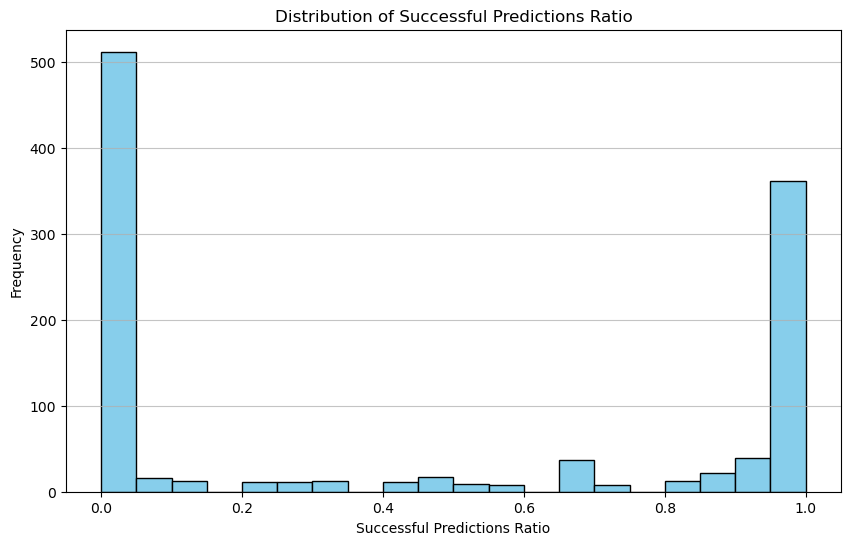

In [15]:
target_df = pd.read_csv('./data/target_prediction_stats.csv')
# 将正负样本比率绘制成直方图
import matplotlib.pyplot as plt
target_df['suc_ratio'] = target_df['successful_predictions'] / (target_df['failed_predictions'] + target_df['successful_predictions']) 
plt.figure(figsize=(10, 6))
plt.hist(target_df['suc_ratio'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Successful Predictions Ratio')
plt.xlabel('Successful Predictions Ratio')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# 从alphafold的预测结果中抽样

In [ ]:
# 按complex执行三点抽样：最好、最差、阈值邻近（邻近样本会剔除已选中的最好/最差）

THRESHOLDS = {
    "scRMSD": 2.5,
    "pep_plddt": 70.0,
    "iptm": 0.7,
}


def add_distance_to_threshold(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["d_threshold"] = (
        ((out["scRMSD"] - THRESHOLDS["scRMSD"]).abs() / THRESHOLDS["scRMSD"])
        + ((out["pep_plddt"] - THRESHOLDS["pep_plddt"]).abs() / THRESHOLDS["pep_plddt"])
        + ((out["iptm"] - THRESHOLDS["iptm"]).abs() / THRESHOLDS["iptm"])
    )
    return out


def pick_best(df: pd.DataFrame) -> pd.Series:
    # 优先级：scRMSD更小更好，其次pep_plddt更大，最后iptm更大
    return df.sort_values(
        by=["scRMSD", "pep_plddt", "iptm"],
        ascending=[True, False, False],
    ).iloc[0]


def pick_worst(df: pd.DataFrame) -> pd.Series:
    # 优先级：scRMSD更大更差，其次pep_plddt更小，最后iptm更小
    return df.sort_values(
        by=["scRMSD", "pep_plddt", "iptm"],
        ascending=[False, True, True],
    ).iloc[0]


def pick_near_threshold_excluding(df: pd.DataFrame, excluded_index: set) -> pd.Series | None:
    candidates = df.loc[~df.index.isin(excluded_index)]
    if candidates.empty:
        return None
    return candidates.sort_values(by=["d_threshold", "scRMSD", "pep_plddt", "iptm"], ascending=[True, True, False, False]).iloc[0]


if "af_df" not in globals():
    af_df = pd.read_csv("./data/af3_metrics_summary_with_labels.csv")

required_cols = {"complex", "label", "scRMSD", "pep_plddt", "iptm", "target"}
missing_cols = required_cols - set(af_df.columns)
if missing_cols:
    raise ValueError(f"af_df缺少必要列: {sorted(missing_cols)}")

work_df = add_distance_to_threshold(af_df)
selected_rows = []
issue_records = []

for complex_name, grp in work_df.groupby("complex", sort=True):
    grp = grp.copy()
    has_pos = (grp["label"] == 1).any()
    has_neg = (grp["label"] == 0).any()

    if has_pos and has_neg:
        best_pool = grp[grp["label"] == 1]
        worst_pool = grp[grp["label"] == 0]
    else:
        best_pool = grp
        worst_pool = grp

    best_row = pick_best(best_pool)
    worst_row = pick_worst(worst_pool)

    chosen_index = {best_row.name, worst_row.name}
    near_row = pick_near_threshold_excluding(grp, chosen_index)

    role_to_row = {
        "best": best_row,
        "worst": worst_row,
    }
    if near_row is not None:
        role_to_row["near_threshold"] = near_row

    # 防御性去重：若best和worst因样本极少发生重叠，只保留一次并记录问题
    dedup = {}
    for role, row in role_to_row.items():
        dedup[row.name] = (role, row)

    if len(dedup) < len(role_to_row):
        issue_records.append({
            "complex": complex_name,
            "issue": "best_worst_overlap",
            "group_size": int(len(grp)),
        })

    for _, (role, row) in dedup.items():
        row_out = row.copy()
        row_out["selection_role"] = role
        row_out["has_pos"] = bool(has_pos)
        row_out["has_neg"] = bool(has_neg)
        selected_rows.append(row_out)

    if near_row is None:
        issue_records.append({
            "complex": complex_name,
            "issue": "no_remaining_candidate_for_near_threshold",
            "group_size": int(len(grp)),
        })

selected_df = pd.DataFrame(selected_rows).reset_index(drop=False).rename(columns={"index": "source_index"})
issues_df = pd.DataFrame(issue_records)

# 质量检查
per_complex_n = selected_df.groupby("complex").size().rename("n_selected")
invalid_complex = per_complex_n[per_complex_n != 3]

print(f"原始样本数: {len(work_df)}")
print(f"complex数量: {work_df['complex'].nunique()}")
print(f"抽样后样本数: {len(selected_df)}")
print(f"每个complex样本数=3 的complex数量: {(per_complex_n == 3).sum()}")
print(f"每个complex样本数!=3 的complex数量: {len(invalid_complex)}")
print(f"问题记录数: {len(issues_df)}")

if len(invalid_complex) > 0:
    print("\n前10个异常complex:")
    print(invalid_complex.head(10))

output_path = "./data/af3_selected_three_points_per_complex.csv"
selected_df.to_csv(output_path, index=False)
print(f"\n已导出: {output_path}")

if len(issues_df) > 0:
    issues_path = "./data/af3_selected_three_points_issues.csv"
    issues_df.to_csv(issues_path, index=False)
    print(f"已导出问题记录: {issues_path}")

selected_df.head()

原始样本数: 16500
complex数量: 1100
抽样后样本数: 3300
每个complex样本数=3 的complex数量: 1100
每个complex样本数!=3 的complex数量: 0
问题记录数: 0

已导出: ./data/af3_selected_three_points_per_complex.csv


,source_index,complex,seed,id,pep_plddt,iptm,ranking_score,scRMSD,label,target,d_threshold,selection_role,has_pos,has_neg
0,2,1a0n_1,42,2,82.0692,0.68,0.80,2.1995,0,1a0n,0.321189,best,False,True
1,8,1a0n_1,43,3,82.7624,0.70,0.81,3.7169,0,1a0n,0.669080,worst,False,True
2,14,1a0n_1,44,4,82.9869,0.70,0.81,2.5236,0,1a0n,0.194967,near_threshold,False,True
3,25,1a0n_10,44,0,80.2376,0.67,0.78,2.7527,0,1a0n,0.290189,best,False,True
4,23,1a0n_10,43,3,77.9586,0.61,0.73,5.9476,0,1a0n,1.621306,worst,False,True


In [9]:
# 新抽样方式：样本中scRMSD、ipTM和pLDDT均小于THRESHOLDS的样本作为假阳性样本，统计每个靶点符合的样本数量
THRESHOLDS = {
    "scRMSD": 2.5,
    "pep_plddt": 70.0,
    "iptm": 0.7,
}

af_df = pd.read_csv("./data/af3_metrics_summary_with_labels.csv")
def count_false_positives(df: pd.DataFrame) -> pd.DataFrame:
    conditions = (
        (df["scRMSD"] <= THRESHOLDS["scRMSD"]) &
        (df["pep_plddt"] < THRESHOLDS["pep_plddt"]) &
        (df["iptm"] < THRESHOLDS["iptm"])
    )
    df["is_false_positive"] = conditions.astype(int)
    false_positive_counts = df.groupby("complex")["is_false_positive"].sum().reset_index(name="false_positive_count")
    return false_positive_counts

def count_true_positives(df: pd.DataFrame) -> pd.DataFrame:
    conditions = (
        (df["scRMSD"] <= THRESHOLDS["scRMSD"]) &
        (df["pep_plddt"] >= THRESHOLDS["pep_plddt"]) &
        (df["iptm"] >= THRESHOLDS["iptm"])
    )
    df["is_true_positive"] = conditions.astype(int)
    true_positive_counts = df.groupby("complex")["is_true_positive"].sum().reset_index(name="true_positive_count")
    return true_positive_counts

def count_false_positives_loosen(df: pd.DataFrame) -> pd.DataFrame:
    conditions = (
        (df["scRMSD"] <= THRESHOLDS["scRMSD"]) &
        (
            (df["pep_plddt"] < THRESHOLDS["pep_plddt"] ) |
            (df["iptm"] < THRESHOLDS["iptm"])
        )
    )
    df["is_false_positive_loosen"] = conditions.astype(int)
    false_positive_counts_loosen = df.groupby("complex")["is_false_positive_loosen"].sum().reset_index(name="false_positive_count_loosen")
    return false_positive_counts_loosen

false_positive_counts_df = count_false_positives(af_df)
false_positive_counts_df.to_csv("./data/af3_scrmsd_lower_pepplddt_lower_iptm_lower_counts_per_target.csv", index=False)
true_positive_counts_df = count_true_positives(af_df)
true_positive_counts_df.to_csv("./data/af3_scrmsd_lower_pepplddt_higher_iptm_higher_counts_per_target.csv", index=False)
false_positive_counts_loosen_df = count_false_positives_loosen(af_df)
false_positive_counts_loosen_df.to_csv("./data/af3_scrmsd_lower_pepplddt_lower_or_iptm_lower_counts_per_target.csv", index=False)


In [17]:
# 检查总共正负样本数量
total_successful = selected_df['label'].sum()
total_failed = len(selected_df) - total_successful
print(f"Total Successful Predictions: {total_successful}")
print(f"Total Failed Predictions: {total_failed}")

Total Successful Predictions: 1437
Total Failed Predictions: 1863


In [18]:
# 从/home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/ligandmpnn_seed42_pdb中软连接指定的pdb文件到/home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/2_combine_af3_train/rosetta/inputs下
import os
import shutil
input_dir = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/ligandmpnn_seed42_pdb"
output_dir = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/2_combine_af3_train/rosetta/inputs"
os.makedirs(output_dir, exist_ok=True)

selected_df['description'] = selected_df.apply(lambda row: f"{row['complex']}_seed-{row['seed']}_sample-{row['id']}_model.pdb.gz", axis=1)

for desc in selected_df['description']:
    src_path = os.path.join(input_dir, desc)
    dst_path = os.path.join(output_dir, desc)
    if os.path.exists(src_path):
        if not os.path.exists(dst_path):
            os.symlink(src_path, dst_path)
    else:
        print(f"Warning: Source file does not exist: {src_path}")
